In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import jax.numpy as jnp
from joblib import Parallel, delayed
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from bilinear_lasso import bilinear_lasso

In [2]:
P, N_SUBJECTS = 264, 422
SPARSITY = 0.08    # 15% of beta elements will be non-zero
SNR = 2          # Signal-to-Noise Ratio
LAMBDA_GRID = [1.5,1.7,1.9,2.1,2.3,2.5]
N_SPLITS, N_JOBS = 5, 5
MAX_ITER, STEP_SIZE, TOL = 2000, 1e-6, 1e-5
DATA_DIR = "/Users/xue6bq/Desktop/Aiying/Data"

In [3]:
def generate_simulation_data(data_dir, p, n, sparsity, snr):
    """
    Generates synthetic data: y = diag(beta.T * X * beta) + noise
    """
    np.random.seed(25)
    
    # 1. Generate random design matrices X1 and X2 (p x p x n)
    z_rs = np.load(os.path.join(data_dir, "z_rs_raw_f_pmat.npy")).reshape((-1, p, p))
    z_emo = np.load(os.path.join(data_dir, "z_emo_raw_f_pmat.npy")).reshape((-1, p, p))
    X1 = jnp.array(np.transpose(z_rs, (1, 2, 0)))
    X2 = jnp.array(np.transpose(z_emo, (1, 2, 0)))
    
    # 2. Generate sparse ground-truth betas
    beta1_true = np.zeros((p, 1))
    beta2_true = np.zeros((p, 1))
    
    n_nonzero = int(p * sparsity)

    X1_mean = np.mean(X1, axis=2)
    X2_mean = np.mean(X2, axis=2)

    X1_centered = X1 - X1_mean[:, :, None]
    X2_centered = X2 - X2_mean[:, :, None]

    # scalar score for each node
    strength1 = np.sum(np.abs(X1_centered), axis=(1, 2))
    strength2 = np.sum(np.abs(X2_centered), axis=(1, 2))

    # choose strongest nodes
    idx1 = np.argsort(strength1)[P-1-n_nonzero:P-1]
    idx2 = np.argsort(strength2)[P-1-n_nonzero:P-1]

    signs1 = np.random.choice([-1, 1], size=(n_nonzero, 1))
    signs2 = np.random.choice([-1, 1], size=(n_nonzero, 1))
    
    beta1_true[idx1] = np.random.uniform(0.5, 2.0, size=(n_nonzero, 1)) * signs1
    beta2_true[idx2] = np.random.uniform(0.5, 2.0, size=(n_nonzero, 1)) * signs2

    
    # 3. Generate y based on the bilinear model
    # Compute: y_i = beta1.T * X1_i * beta1 + beta2.T * X2_i * beta2
    def get_signal(X, b):
        # b is (p, 1), X is (p, p, n)
        b_flat = np.array(b).flatten()
        return np.einsum("i,ijk,j->k", b_flat, X, b_flat)
    
    
    signal = get_signal(X1_centered, beta1_true) + get_signal(X2_centered, beta2_true)
    
    # 4. Add noise based on SNR
    sigma = np.std(signal) / snr
    noise = np.random.normal(0, sigma, size=n)
    y = signal + noise
    
    return jnp.array(X1), jnp.array(X2), jnp.array(y), beta1_true, beta2_true

def load_fmri_data(data_dir, p=264, n_subjects=None):
    z_rs = np.load(os.path.join(data_dir, "z_rs_raw_f_pmat.npy")).reshape((-1, p, p))
    z_emo = np.load(os.path.join(data_dir, "z_emo_raw_f_pmat.npy")).reshape((-1, p, p))
    y = np.load(os.path.join(data_dir, "y_f_pmat.npy"))
    age = np.load(os.path.join(data_dir, "age_f_pmat.npy"))
    
    # Transpose to p x p x n (nodes, nodes, subjects)
    X1 = jnp.array(np.transpose(z_rs, (1, 2, 0)))
    X2 = jnp.array(np.transpose(z_emo, (1, 2, 0)))
    y = jnp.array(y)
    age = jnp.array(age)
    
    print(f"Loaded Data: X1={X1.shape}, X2={X2.shape}, y={y.shape}, age={age.shape}")
    return X1, X2, y, age

In [4]:
def predict_bilinear(X1, X2, beta1, beta2):
    b1 = np.array(beta1).flatten()
    b2 = np.array(beta2).flatten()
    return (np.einsum("i,ijk,j->k", b1, X1, b1) + 
            np.einsum("i,ijk,j->k", b2, X2, b2))

def evaluate_prediction(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mse = np.mean((y_true - y_pred) ** 2)
    var_y = np.var(y_true)
    r2 = 1 - mse / var_y if var_y > 1e-9 else np.nan
    corr = np.corrcoef(y_true, y_pred)[0, 1] if np.std(y_pred) > 1e-9 else 0
    return {"mse": float(mse), "r2": float(r2), "corr": float(corr)}

def compute_r2(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)

    if tss < 1e-12:
        return np.nan

    return 1 - rss / tss


def compute_corr(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    if np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        return np.nan

    return np.corrcoef(y_true, y_pred)[0, 1]

def calculate_ebic(mse, n_features, n_samples, total_p, gamma=0.5):
    if mse <= 1e-12:
        return -np.inf, -np.inf

    bic = n_samples * np.log(mse) + n_features * np.log(n_samples)
    ebic = bic + 2 * gamma * n_features * np.log(total_p)

    return bic, ebic

In [5]:
def run_one_cv_fold(
    X1, X2, y,
    train_idx, val_idx,
    lam, p,
    max_iter, step_size, tol
):
    # Split data
    X1_tr, X1_val = X1[:, :, train_idx], X1[:, :, val_idx]
    X2_tr, X2_val = X2[:, :, train_idx], X2[:, :, val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # Center using training means only
    y_tr_m = y_tr.mean()
    y_val_m = y_val.mean()
    y_tr_c = y_tr - y_tr_m
    y_val_c = y_val - y_val_m

    X1_tr_m = X1_tr.mean(axis=2, keepdims=True)
    X2_tr_m = X2_tr.mean(axis=2, keepdims=True)

    X1_val_m = X1_val.mean(axis=2, keepdims=True)
    X2_val_m = X2_val.mean(axis=2, keepdims=True)

    X1_tr_c = X1_tr - X1_tr_m
    X1_val_c = X1_val - X1_val_m

    X2_tr_c = X2_tr - X2_tr_m
    X2_val_c = X2_val - X2_val_m

    # Fit model
    model = bilinear_lasso(X1_tr_c, X2_tr_c, y_tr_c, lam, lam)

    model.initialize_beta(
        jnp.zeros((p, 1)),
        jnp.zeros((p, 1))
    )

    model.fit(
        num_candidates=1,
        max_iter=max_iter,
        step_size=step_size,
        tol=tol,
        disturbance=2
    )

    beta1 = np.asarray(model.beta1).ravel()
    beta2 = np.asarray(model.beta2).ravel()

    supp1 = np.where(np.abs(beta1) > 0.2)[0]
    supp2 = np.where(np.abs(beta2) > 0.2)[0]
    n_features = len(supp1) + len(supp2)

    # Predictions
    y_pred_tr = np.asarray(
        predict_bilinear(X1_tr_c, X2_tr_c, model.beta1, model.beta2)
    ).ravel()

    y_pred_val = np.asarray(
        predict_bilinear(X1_val_c, X2_val_c, model.beta1, model.beta2)
    ).ravel()

    y_tr_c = np.asarray(y_tr_c).ravel()
    y_val_c = np.asarray(y_val_c).ravel()

    # Metrics
    train_metrics = evaluate_prediction(y_tr_c, y_pred_tr)
    val_metrics = evaluate_prediction(y_val_c, y_pred_val)

    bic, ebic = calculate_ebic(
        train_metrics["mse"],
        n_features,
        len(train_idx),
        p * 2
    )

    return {
        "lambda": lam,

        "train_mse": train_metrics["mse"],
        "train_r2": train_metrics["r2"],
        "train_corr": train_metrics["corr"],

        "val_mse": val_metrics["mse"],
        "val_r2": val_metrics["r2"],
        "val_corr": val_metrics["corr"],

        "bic": float(bic),
        "ebic": float(ebic),

        "supp1": supp1,
        "supp2": supp2,
        "n_features": n_features,

        "beta1": beta1,
        "beta2": beta2,

        "y_train_true": y_tr_c,
        "y_train_pred": y_pred_tr,
        "y_true": y_val_c,
        "y_pred": y_pred_val
    }


# ============================================================
# One lambda CV
# ============================================================

def run_one_lambda_cv(lam, X1, X2, y):
    kf = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=1999
    )

    folds = [
        run_one_cv_fold(
            X1, X2, y,
            train_idx, val_idx,
            lam, P,
            MAX_ITER, STEP_SIZE, TOL
        )
        for train_idx, val_idx in kf.split(np.arange(y.shape[0]))
    ]

    result = {
        "lambda": lam,

        "mean_train_r2": np.mean([f["train_r2"] for f in folds]),
        "mean_train_corr": np.mean([f["train_corr"] for f in folds]),
        "mean_train_mse": np.mean([f["train_mse"] for f in folds]),

        "mean_r2": np.mean([f["val_r2"] for f in folds]),
        "mean_corr": np.mean([f["val_corr"] for f in folds]),
        "mean_mse": np.mean([f["val_mse"] for f in folds]),
        "sd_mse": np.std([f["val_mse"] for f in folds]),

        "mean_bic": np.mean([f["bic"] for f in folds]),
        "mean_ebic": np.mean([f["ebic"] for f in folds]),

        "cv_stability": (
            np.std([f["val_mse"] for f in folds])
            / np.mean([f["val_mse"] for f in folds])
        ),

        "mean_features": np.mean([f["n_features"] for f in folds]),
        "folds": folds
    }

    return result


# ============================================================
# Run CV over lambda grid
# ============================================================

def run_cv_over_lambdas(X1, X2, y):
    results = Parallel(n_jobs=N_JOBS)(
        delayed(run_one_lambda_cv)(lam, X1, X2, y)
        for lam in LAMBDA_GRID
    )

    summary_df = pd.DataFrame([
        {
            "lambda": r["lambda"],

            "Train R2": r["mean_train_r2"],
            "Test R2": r["mean_r2"],

            "Train Corr": r["mean_train_corr"],
            "Test Corr": r["mean_corr"],

            "Train MSE": r["mean_train_mse"],
            "Test MSE": r["mean_mse"],

            "Avg Features": r["mean_features"],

            "BIC": r["mean_bic"],
            "EBIC": r["mean_ebic"],

            "Stability": r["cv_stability"]
        }
        for r in results
    ])

    summary_df["Gap"] = summary_df["Train R2"] - summary_df["Test R2"]

    summary_df = summary_df.sort_values("EBIC")

    return results, summary_df


def plot_train_test_grid_all_lambdas(results):
    """
    Creates a (2 * number_of_lambdas) x 5 grid.

    For each lambda:
        row 1 = training predictions
        row 2 = validation/test predictions
    """

    n_lambdas = len(results)
    n_folds = len(results[0]["folds"])

    fig, axes = plt.subplots(
        2 * n_lambdas,
        n_folds,
        figsize=(4.2 * n_folds, 3.2 * 2 * n_lambdas),
        sharex=False,
        sharey=False
    )

    if n_lambdas == 1:
        axes = np.asarray(axes).reshape(2, n_folds)

    for l_idx, result in enumerate(results):

        lam = result["lambda"]
        folds = result["folds"]

        train_row = 2 * l_idx
        test_row = 2 * l_idx + 1

        # Shared axis limits within each lambda
        all_values = []

        for fold in folds:
            all_values.extend(np.asarray(fold["y_train_true"]).ravel())
            all_values.extend(np.asarray(fold["y_train_pred"]).ravel())
            all_values.extend(np.asarray(fold["y_true"]).ravel())
            all_values.extend(np.asarray(fold["y_pred"]).ravel())

        all_values = np.asarray(all_values)

        mn = np.min(all_values)
        mx = np.max(all_values)

        buffer = 0.05 * (mx - mn)
        mn -= buffer
        mx += buffer

        for f_idx, fold in enumerate(folds):

            # ----------------------------
            # Training scatter
            # ----------------------------
            ax = axes[train_row, f_idx]

            y_train_true = np.asarray(fold["y_train_true"]).ravel()
            y_train_pred = np.asarray(fold["y_train_pred"]).ravel()

            ax.scatter(
                y_train_true,
                y_train_pred,
                alpha=0.45,
                s=12
            )

            ax.plot(
                [mn, mx],
                [mn, mx],
                linestyle="--",
                linewidth=1
            )

            ax.set_xlim(mn, mx)
            ax.set_ylim(mn, mx)

            ax.set_title(
                f"Fold {f_idx + 1}\n"
                f"Train R²={fold['train_r2']:.2f}, "
                f"r={fold['train_corr']:.2f}",
                fontsize=9
            )

            if f_idx == 0:
                ax.set_ylabel(
                    f"$\\lambda$={lam}\nTrain\nPredicted y"
                )

            ax.set_xlabel("True y")

            # ----------------------------
            # Validation/test scatter
            # ----------------------------
            ax = axes[test_row, f_idx]

            y_true = np.asarray(fold["y_true"]).ravel()
            y_pred = np.asarray(fold["y_pred"]).ravel()

            ax.scatter(
                y_true,
                y_pred,
                alpha=0.65,
                s=18
            )

            ax.plot(
                [mn, mx],
                [mn, mx],
                linestyle="--",
                linewidth=1
            )

            ax.set_xlim(mn, mx)
            ax.set_ylim(mn, mx)

            ax.set_title(
                f"Fold {f_idx + 1}\n"
                f"Test R²={fold['val_r2']:.2f}, "
                f"r={fold['val_corr']:.2f}",
                fontsize=9
            )

            if f_idx == 0:
                ax.set_ylabel(
                    f"$\\lambda$={lam}\nTest\nPredicted y"
                )

            ax.set_xlabel("True y")

    fig.suptitle(
        "Training and validation predictions across lambdas and folds",
        fontsize=16,
        y=1.002
    )

    plt.tight_layout()
    plt.show()


Loaded Data: X1=(264, 264, 422), X2=(264, 264, 422), y=(422,), age=(422,)


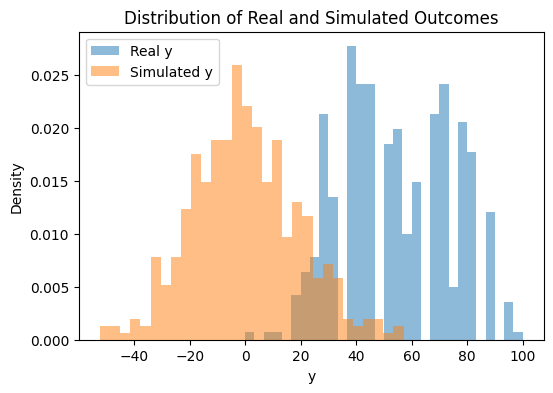

In [6]:
X1_sim, X2_sim, y_sim, b1_true, b2_true = generate_simulation_data(DATA_DIR, P, N_SUBJECTS, SPARSITY, SNR)
X1, X2, y, _ = load_fmri_data(DATA_DIR, P, N_SUBJECTS)
plt.figure(figsize=(6,4))

plt.hist(
    y,
    bins=30,
    alpha=0.5,
    density=True,
    label="Real y"
)

plt.hist(
    y_sim,
    bins=30,
    alpha=0.5,
    density=True,
    label="Simulated y"
)

plt.xlabel("y")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of Real and Simulated Outcomes")

plt.show()

0 th try
initialized loss: 76078.90625


  0%|          | 0/2000 [00:00<?, ?it/s]

0 th try
initialized loss: 223338.875


  0%|          | 8/2000 [00:01<02:59, 11.11it/s]

0 th try
initialized loss: 64649.78515625


...

Job took:  69.43557596206665
Final loss: 311.4186096191406
Final loss: 311.4186096191406
0 th try
initialized loss: 74314.40625


100%|██████████| 2000/2000 [01:09<00:00, 28.82it/s]


Job took:  69.41223120689392
Final loss: 324.1600341796875
Final loss: 324.1600341796875
0 th try
initialized loss: 127438.4296875


100%|██████████| 2000/2000 [01:08<00:00, 29.22it/s]


Job took:  68.46523785591125
Final loss: 286.8314514160156
Final loss: 286.8314514160156


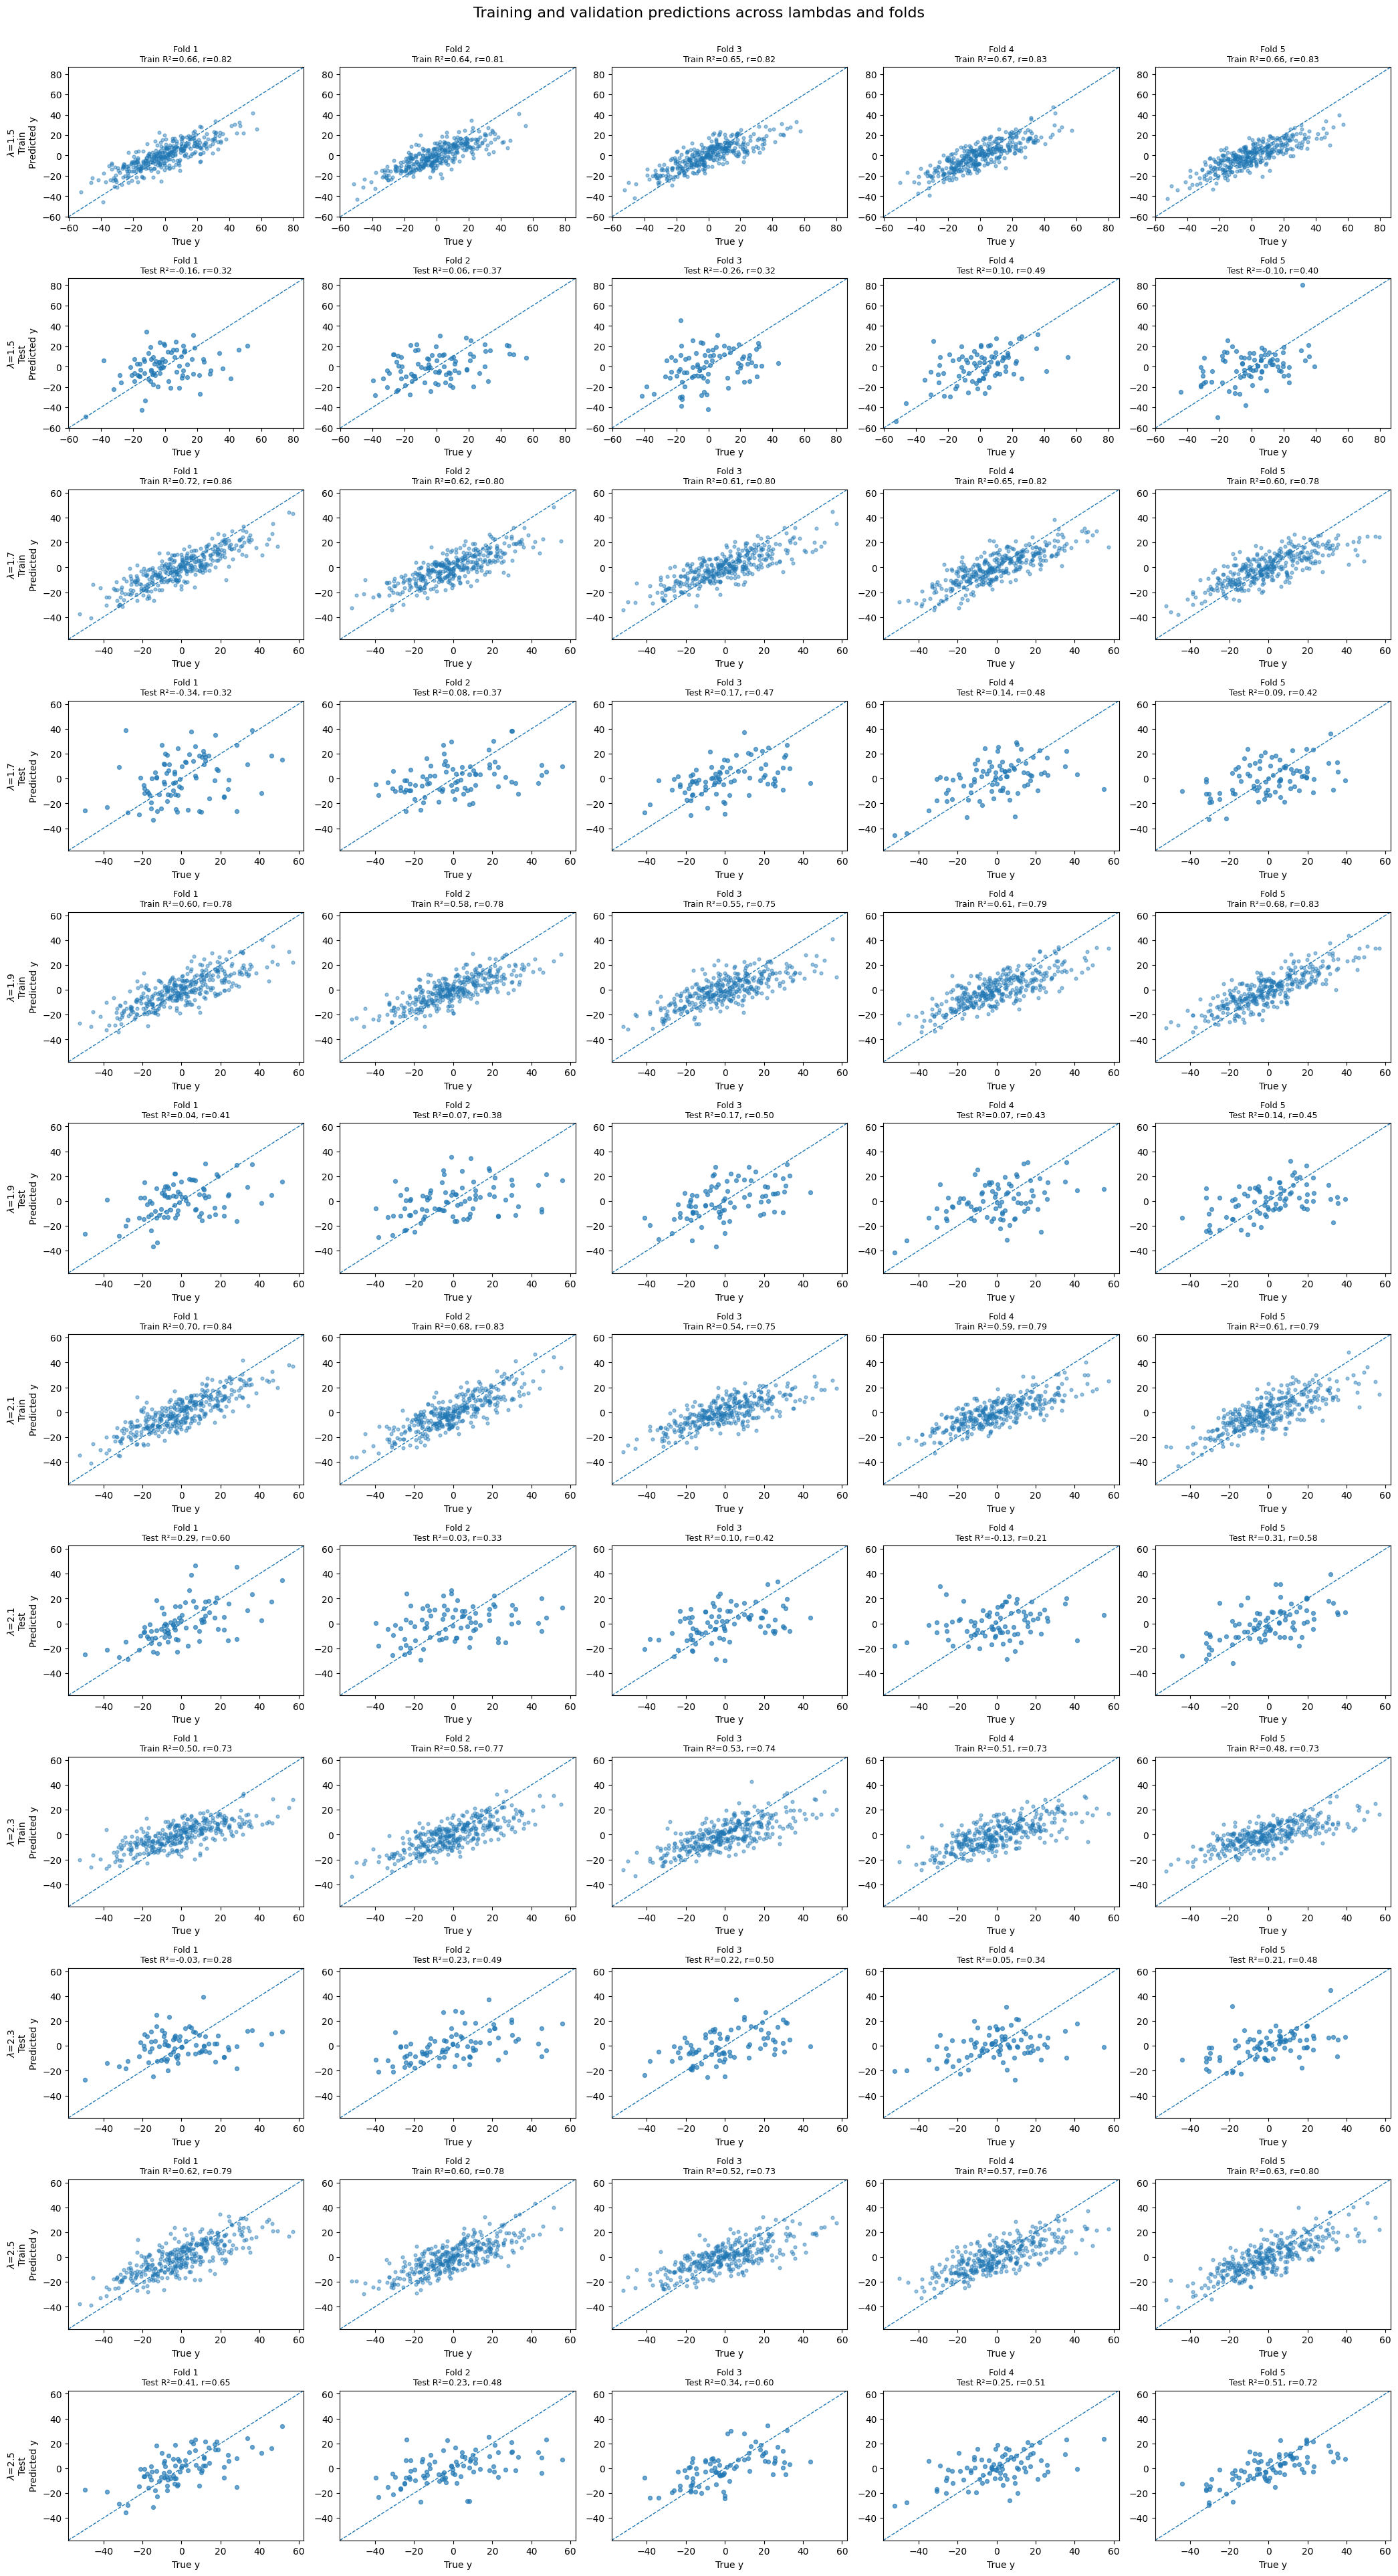

,lambda,Train R2,Test R2,Train Corr,Test Corr,Train MSE,Test MSE,Avg Features,BIC,EBIC,Stability,Gap
5,2.5,0.587720,0.347217,0.772647,0.591817,148.185483,237.374152,136.6,2481.029781,3337.388334,0.268341,0.240504
4,2.3,0.520552,0.135939,0.738849,0.417572,172.668420,307.583832,149.4,2607.223851,3543.826836,0.121271,0.384614
3,2.1,0.625179,0.117799,0.800074,0.427357,134.984637,319.707828,179.2,2694.101976,3817.524030,0.264344,0.507380
2,1.9,0.603033,0.096321,0.784850,0.431615,142.529964,324.672095,188.0,2766.889417,3945.479518,0.153421,0.506712
1,1.7,0.640035,0.030167,0.810609,0.414926,129.206277,345.551495,202.0,2814.877909,4081.235359,0.189428,0.609868
0,1.5,0.657495,-0.069355,0.822214,0.379129,123.005457,379.851776,239.6,3019.433692,4521.509161,0.107413,0.726850


In [7]:
results_sim, summary_df_sim = run_cv_over_lambdas(X1_sim, X2_sim, y_sim)
plot_train_test_grid_all_lambdas(results_sim)
display(summary_df_sim)

In [8]:
X1, X2, y, age = load_fmri_data(DATA_DIR, P, N_SUBJECTS)
from sklearn.linear_model import LinearRegression
import numpy as np

age = age.reshape(-1, 1)

model = LinearRegression()

model.fit(age, y)

y_hat = model.predict(age)

y_resid = y - y_hat

Loaded Data: X1=(264, 264, 422), X2=(264, 264, 422), y=(422,), age=(422,)


0 th try
initialized loss: 63906.82421875


  0%|          | 0/2000 [00:00<?, ?it/s]7.93it/s]

0 th try
initialized loss: 164710.46875
0 th try
initialized loss: 88127.1953125


  5%|▍         | 97/2000 [00:04<01:32, 20.47it/s]

0 th try
initialized loss: 180595.546875


...

Job took:  64.54311299324036
Final loss: 353.6214599609375
Final loss: 353.6214599609375
0 th try
initialized loss: 84863.25


100%|██████████| 2000/2000 [01:04<00:00, 31.06it/s]


Job took:  64.40573501586914
Final loss: 370.4188232421875
Final loss: 370.4188232421875
0 th try
initialized loss: 54658.1328125


100%|██████████| 2000/2000 [01:04<00:00, 30.98it/s]


Job took:  64.5573513507843
Final loss: 347.6357421875
Final loss: 347.6357421875


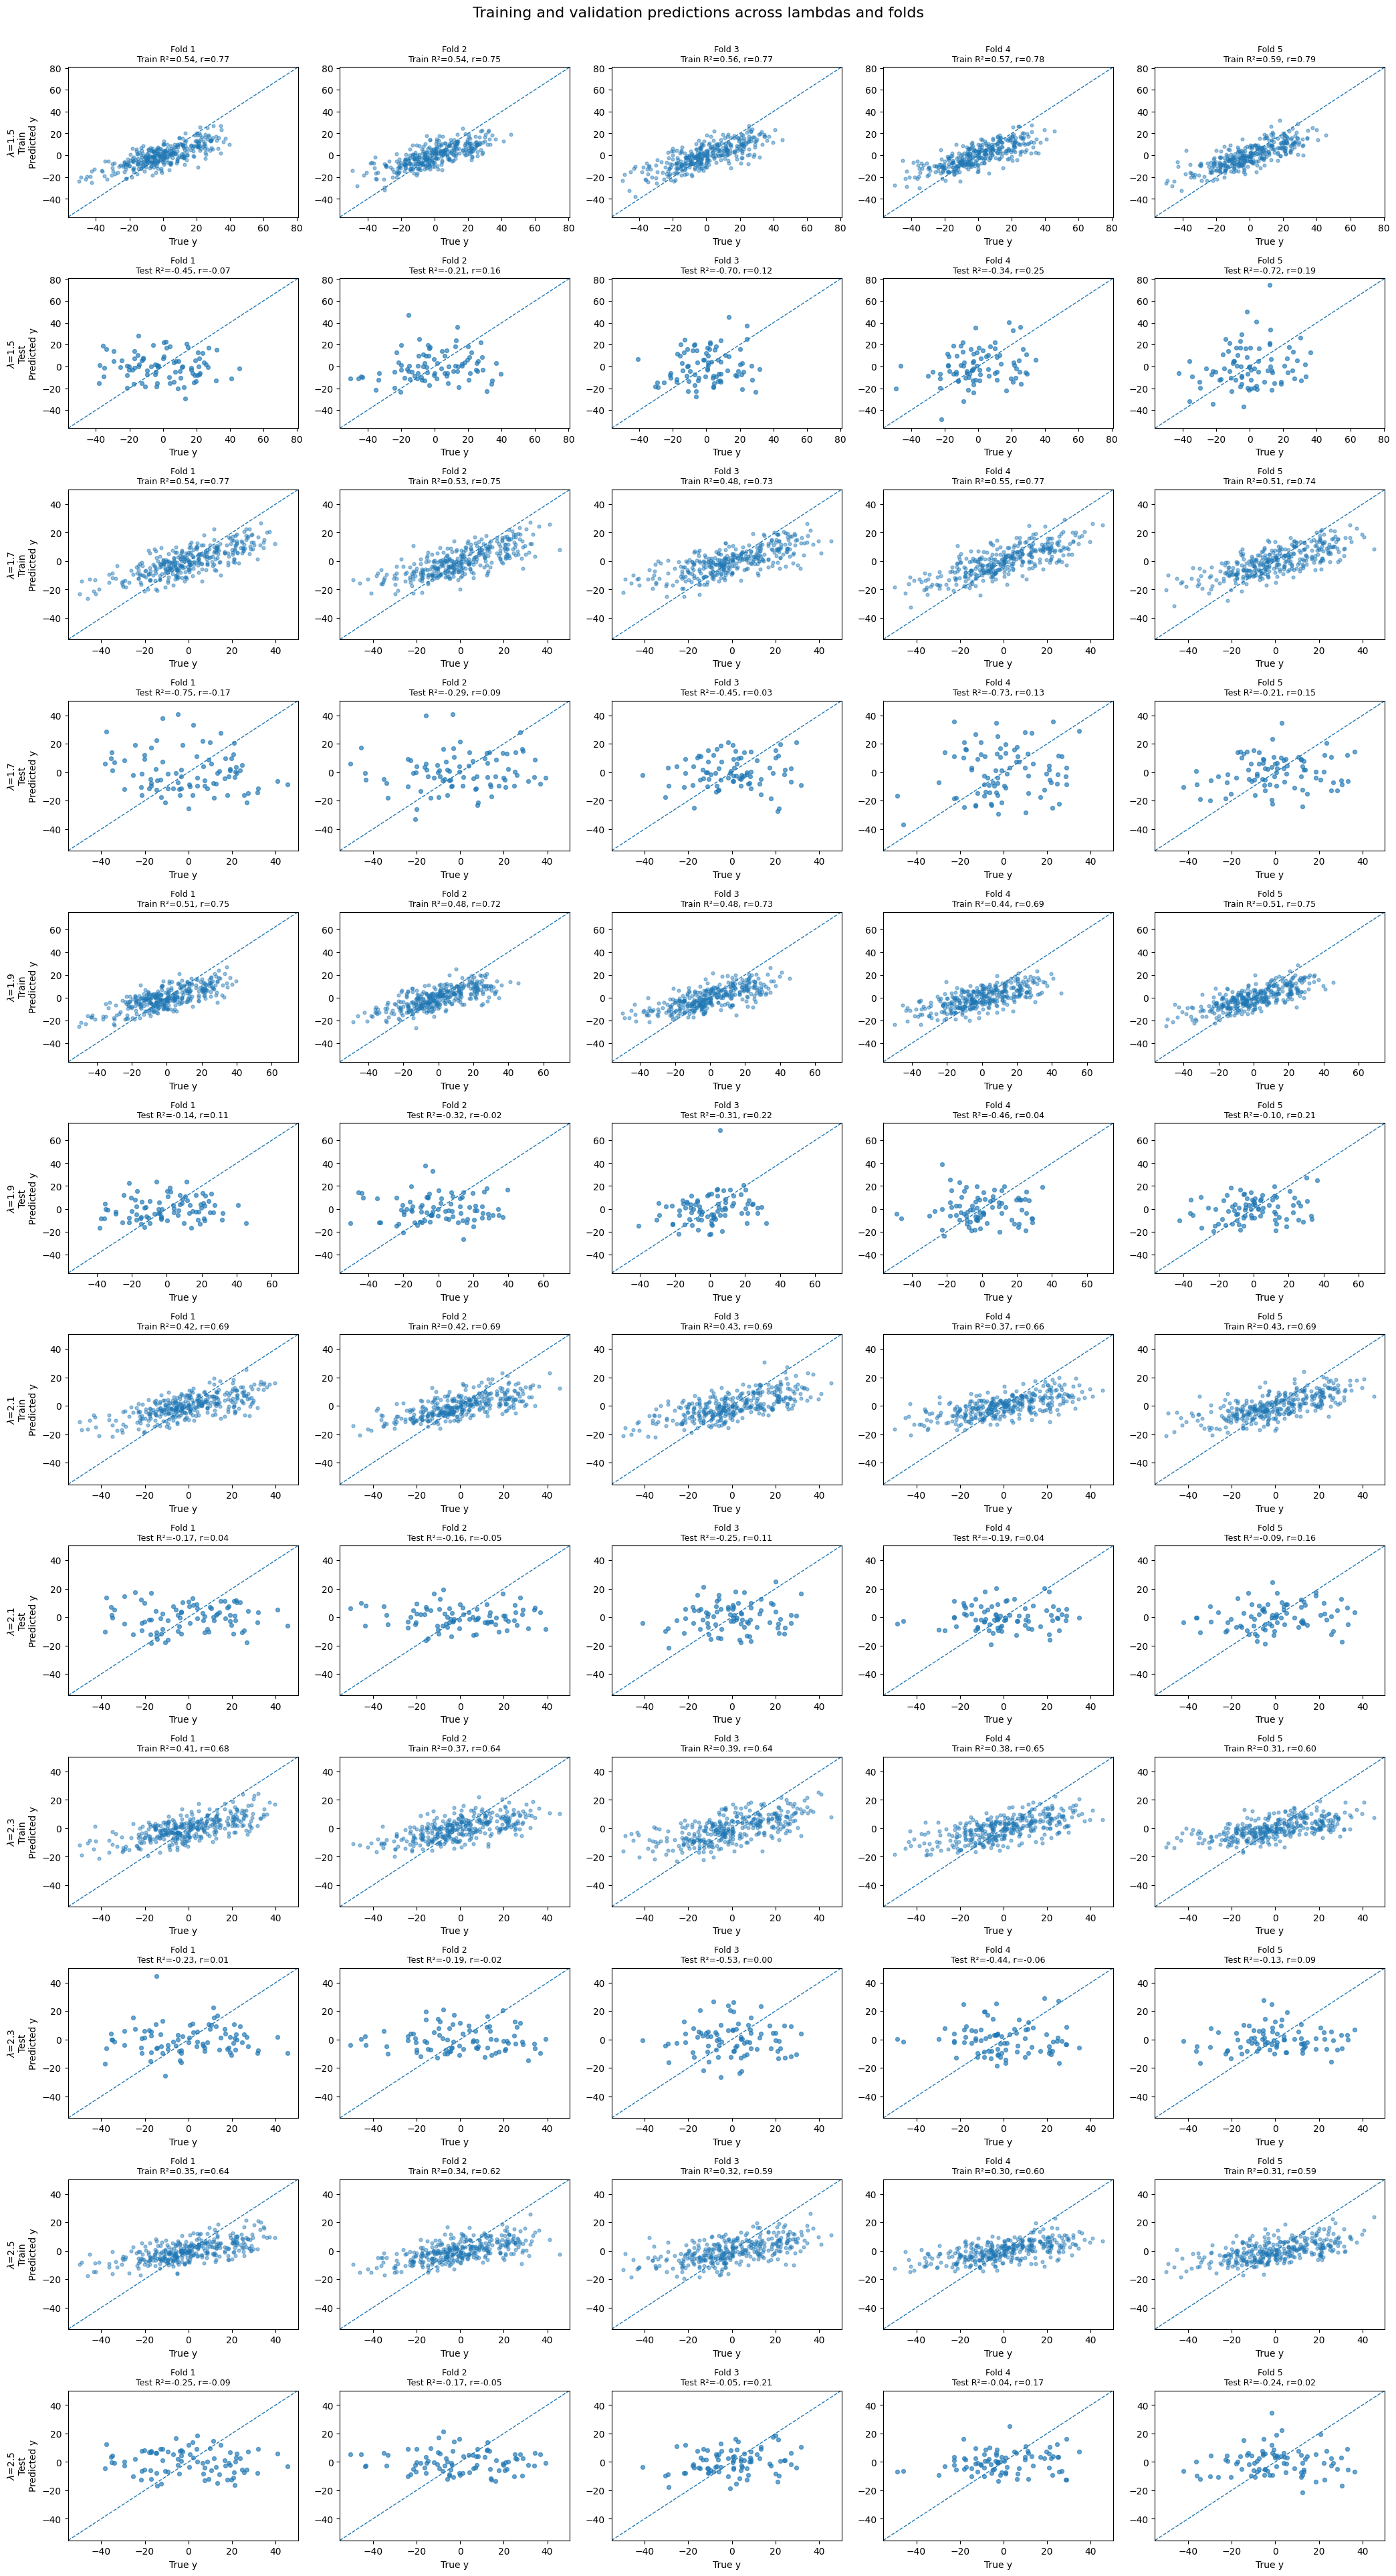

,lambda,Train R2,Test R2,Train Corr,Test Corr,Train MSE,Test MSE,Avg Features,BIC,EBIC,Stability,Gap
5,2.5,0.325666,-0.151490,0.609854,0.053432,217.228943,373.943652,152.6,2704.196991,3660.861084,0.252057,0.477155
4,2.3,0.371237,-0.304002,0.642542,0.004889,202.404083,411.937286,155.0,2694.189075,3665.898999,0.141346,0.675238
3,2.1,0.410868,-0.171934,0.683567,0.060578,189.666037,375.265338,165.6,2734.148325,3772.310670,0.190670,0.582802
2,1.9,0.483938,-0.265665,0.727074,0.111668,166.214197,404.708954,196.0,2866.184131,4094.927003,0.205274,0.749603
1,1.7,0.522918,-0.486445,0.752768,0.044414,153.765021,477.212543,217.2,2963.165922,4324.813635,0.246253,1.009363
0,1.5,0.560491,-0.483739,0.772392,0.129098,141.240054,468.084930,247.8,3113.663111,4667.145170,0.146232,1.044230


In [9]:
results, summary_df = run_cv_over_lambdas(X1, X2, y_resid)
plot_train_test_grid_all_lambdas(results)
display(summary_df)

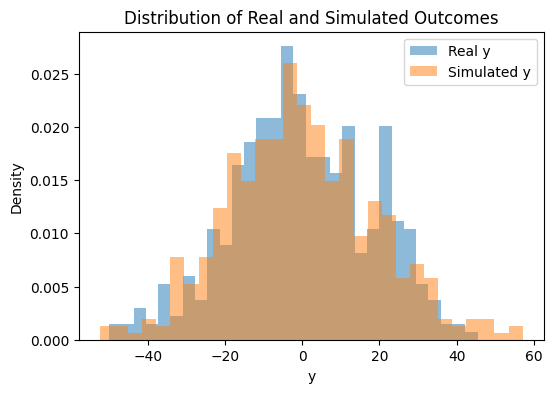

In [10]:
plt.figure(figsize=(6,4))

plt.hist(
    y_resid,
    bins=30,
    alpha=0.5,
    density=True,
    label="Real y"
)

plt.hist(
    y_sim,
    bins=30,
    alpha=0.5,
    density=True,
    label="Simulated y"
)

plt.xlabel("y")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of Real and Simulated Outcomes")

plt.show()